## Preparation

In [1]:
import os
import anndata
import scanpy as sc
import random
import torch
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import sys
import os

from pathlib import Path
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import silhouette_score as s_score

stClinic_root = r'E:\yan0\multi-sample-disentangle\baseline\stClinic-main\stClinic-main'
if os.path.exists(stClinic_root) and stClinic_root not in sys.path:
    sys.path.insert(0, stClinic_root)

import stClinic as stClinic

warnings.filterwarnings("ignore")

d:\anaconda3\envs\disent\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
d:\anaconda3\envs\disent\Lib\site-packages\torch\cuda\__init__.py:54: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
d:\anaconda3\envs\disent\Lib\site-packages\torch_geometric\__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not find module 'D:\anaconda3\envs\disent\Lib\site-packages\libpyg.pyd' (or one of its dependencies). Try using the full path with co

OSError: [WinError 127] 找不到指定的程序。

In [3]:
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(used_device)

cuda:0


In [4]:
# Set seed
seed    = 666
np.random.seed(seed)
random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

## Load Data

In [5]:
adata = sc.read_h5ad('E:/yan0/multi-sample-disentangle/multi-sample-data/UTAG/infected_lung_adata.h5ad')

In [6]:
Batch_list  = []
adj_list    = []

In [7]:
adata1 = adata[adata.obs['disease']=='Healthy']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[21]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

adata2.obs_names = [x+'_'+ '1' for x in adata2.obs_names]

# Construct intra-edges
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=20)

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 36144 edges, 7097 cells.
5.0929 neighbors per spot on average.


In [7]:
adata1 = adata[adata.obs['disease']=='Healthy']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[-6]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '2' for x in adata2.obs_names]

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 19860 edges, 7199 cells.
2.7587 neighbors per spot on average.


In [8]:
adata1 = adata[adata.obs['disease'] == 'ARDS']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[27]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '3' for x in adata2.obs_names]

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 36932 edges, 8817 cells.
4.1887 neighbors per spot on average.


In [9]:
adata1 = adata[adata.obs['disease'] == 'COVID19']
adata2 = adata1[adata1.obs['roi'] == adata1.obs['roi'].unique()[39]]

adata2.var_names_make_unique(join="++")
adata2.obs['Ground Truth'] = adata2.obs['metacluster_label'].astype('category')

# make spot name unique
adata2.obs_names = [x+'_'+ '4' for x in adata2.obs_names]

# Constructing the spatial network
stClinic.Cal_Spatial_Net(adata2, rad_cutoff=20) # the spatial network are saved in adata.uns[‘adj’]

adj_list.append(adata2.uns['adj'])
Batch_list.append(adata2)

------Calculating intra-spatial graph...
The graph contains 10676 edges, 3797 cells.
2.8117 neighbors per spot on average.


In [10]:
section_ids = [str(i+1) for i in range(len(Batch_list))]

In [11]:
# Concat scanpy objects
adata_concat = anndata.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['Ground Truth'].astype('category')
adata_concat.obs["batch_name"]   = adata_concat.obs["slice_name"].astype('category')
print('\nShape of concatenated AnnData object: ', adata_concat.shape)

# Construct unified graph
# mnn_dict = create_dictionary_mnn(adata_concat, use_rep='X_pca', batch_name='batch_name', k=1) # k=0
adj_concat = stClinic.inter_linked_graph(adj_list, section_ids, mnn_dict=None)
adata_concat.uns['adj']      = adj_concat
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)


Shape of concatenated AnnData object:  (19711, 43)


## Running STAligner

In [12]:
# Run stClinic for unsupervised integration
centroids_num = 6
print(f'Estimated centroids number: {centroids_num}')
adata_concat  = stClinic.train_stClinic_model(adata_concat, n_centroids=centroids_num, lr=0.0005, device=used_device)

# Clustering
stClinic.mclust_R(adata_concat, num_cluster=len(np.unique(adata_concat.obs[adata_concat.obs['Ground Truth']!='unknown']['Ground Truth'])), used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

Batch_list1   = []
for section_id in section_ids:
	Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

Estimated centroids number: 6
Pretrain with unregularized stClinic (without GMM regularizer)...


Epochs:   0%|          | 0/300 [00:00<?, ?it/s]

Initialize Gaussian Mixture Model...
Selected initial type: GMM
Train with regularized stClinic (with GMM regularizer)...


Epochs:   0%|          | 0/400 [00:00<?, ?it/s]

Prune edges...
Prune edges...


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [13]:
adata_concat

View of AnnData object with n_obs × n_vars = 19711 × 43
    obs: 'roi', 'sample', 'disease', 'phenotypes', 'acquisition_id', 'acquisition_date', 'obj_id', 'cluster_1.0', 'cluster_label', 'metacluster_label', 'X', 'Y', 'Ground Truth', 'slice_name', 'batch_name', 'GMM_cluster', 'mclust'
    uns: 'adj', 'edgeList'
    obsm: 'X_pca', 'X_umap', 'spatial', 'stClinic'

## Clustering

In [14]:
stClinic.mclust_R(adata_concat, num_cluster=6, used_obsm='stClinic')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

fitting ...
  |======================================================================| 100%
mclust, ARI = 0.168


## Visualization

In [ ]:
# import os
# import matplotlib.pyplot as plt
# from sklearn.metrics import adjusted_rand_score as ari_score

# # 保存目录（stClinic）
# save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering"
# os.makedirs(save_dir, exist_ok=True)

# # 取3个 slice（如果 section_ids 超过3个，只取前3个）
# section_ids_3 = list(section_ids)[:3]
# Batch_list1 = [adata_concat[adata_concat.obs["batch_name"] == sid] for sid in section_ids_3]

# spot_size = 15
# title_size = 12

# # 计算3个样本 ARI（保留6位）
# ARI_list = []
# for ad in Batch_list1:
#     ari = float(ari_score(ad.obs["Ground Truth"], ad.obs["mclust"]))
#     ARI_list.append(round(ari, 6))

# # 分别保存每个 slice：不要 legend + 黑色边框
# for i, ad in enumerate(Batch_list1, start=1):
#     fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)

#     sc.pl.spatial(
#         ad,
#         img_key=None,
#         color=["mclust"],
#         title=[""],
#         legend_loc=None,      # 不显示 legend
#         show=False,
#         ax=ax,
#         frameon=True,
#         spot_size=spot_size,
#     )

#     # ARI标题
#     # ax.set_title(f"ARI={ARI_list[i-1]:.2f}", size=title_size)

#     # 去坐标轴信息
#     ax.set_xlabel("")
#     ax.set_ylabel("")
#     ax.set_xticks([])
#     ax.set_yticks([])
#     ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

#     # 黑色边框
#     for spine in ax.spines.values():
#         spine.set_visible(True)
#         spine.set_color("black")
#         spine.set_linewidth(1.5)

#     out_path = os.path.join(save_dir, f"slice{i}_mclust.png")
#     fig.savefig(out_path)   # 不用 tight，保证各图尺寸一致
#     plt.close(fig)

#     print(f"Saved: {out_path}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\slice1_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\slice2_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\slice3_mclust.png


In [21]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score

# 保存目录（stClinic）
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering"
os.makedirs(save_dir, exist_ok=True)

Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs["batch_name"] == section_id])

spot_size = 15
title_size = 12

# 计算每个样本 ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(
        round(
            ari_score(
                Batch_list1[bb].obs["Ground Truth"],
                Batch_list1[bb].obs["mclust"],
            ),
            2,
        )
    )

# 分别保存每个 sample 的单图：无 legend + 黑边框
for bb in range(n_batches):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    sc.pl.spatial(
        Batch_list1[bb],
        img_key=None,
        color=["mclust"],
        title=[""],
        legend_loc=None,   # 不显示 legend
        show=False,
        ax=ax,
        frameon=True,      # 开启边框
        spot_size=spot_size,
    )

    # ARI 标题
    # ax.set_title(f"ARI={ARI_list[bb]}", size=title_size)

    # 去坐标轴信息（如要保留可删）
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    out_path = os.path.join(save_dir, f"sample_{bb+1}_mclust.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\sample_1_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\sample_2_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/stClinic/clustering\sample_3_mclust.png


In [18]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ari_score

# 1) 重新计算3个slice的ARI（不提前round）
section_ids_3 = list(section_ids)[:3]
Batch_list1 = [adata_concat[adata_concat.obs["batch_name"] == sid] for sid in section_ids_3]

ari_values = []
for ad in Batch_list1:
    ari_values.append(float(ari_score(ad.obs["Ground Truth"], ad.obs["mclust"])))

# 2) 保存到统一 metrics/ari.csv
method_name = "stClinic"
metrics_dir = r"E:\yan0\multi-sample-disentangle\results\lung_infected\metrics"
os.makedirs(metrics_dir, exist_ok=True)
csv_path = os.path.join(metrics_dir, "ari.csv")

vals = ari_values[:3] + [np.nan] * max(0, 3 - len(ari_values))

new_row = pd.DataFrame([{
    "method": method_name,
    "sample1_ari": vals[0],
    "sample2_ari": vals[1],
    "sample3_ari": vals[2],
}])

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    if "method" in df.columns and (df["method"] == method_name).any():
        df.loc[df["method"] == method_name, ["sample1_ari", "sample2_ari", "sample3_ari"]] = vals
    else:
        df = pd.concat([df, new_row], ignore_index=True)
else:
    df = new_row

# 固定6位小数写出
df.to_csv(csv_path, index=False, encoding="utf-8-sig", float_format="%.6f")

print("Saved:", csv_path)
print("Current row:", new_row.to_dict(orient="records")[0])

Saved: E:\yan0\multi-sample-disentangle\results\lung_infected\metrics\ari.csv
Current row: {'method': 'stClinic', 'sample1_ari': 0.1394838770881932, 'sample2_ari': 0.22834156273945203, 'sample3_ari': 0.17780250442954812}


In [ ]:
# UMAP reduction
sc.pp.neighbors(adata_concat, use_rep='stClinic', random_state=seed)
sc.tl.umap(adata_concat, random_state=seed)

Text(0.5, 1.0, 'ARI=0.2')

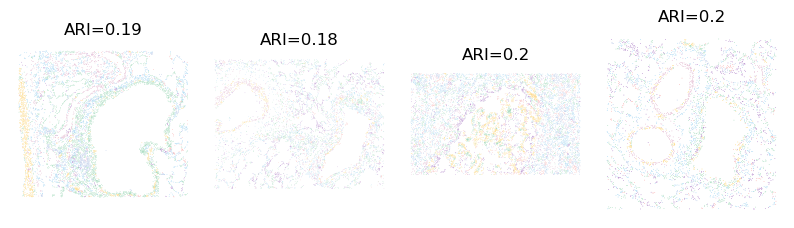

In [20]:

spot_size  = 6
title_size = 12
ARI_list   = []
for bb in range(4):
	ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

colors  = ["#6D1A9B", "#CB79A6", "#7494D2", "#59BD85", "#56B3E8", "#FDB815", "#F46867"]
fig, ax = plt.subplots(1, 4, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

_sc_0 = sc.pl.spatial(Batch_list1[0], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None, 
					  legend_fontsize=12, show=False, ax=ax[0], frameon=False, palette=colors)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=12)
_sc_1 = sc.pl.spatial(Batch_list1[1], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[1], frameon=False, palette=colors)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=12)
_sc_2 = sc.pl.spatial(Batch_list1[2], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[2], frameon=False, palette=colors)
_sc_2[0].set_title("ARI=" + str(ARI_list[2]), size=12)
_sc_3 = sc.pl.spatial(Batch_list1[3], img_key=None, color=['mclust'], title=[''],spot_size=spot_size, legend_loc=None,
					  legend_fontsize=12, show=False, ax=ax[3], frameon=False, palette=colors)
_sc_3[0].set_title("ARI=" + str(ARI_list[3]), size=12)

Text(0.5, 1.0, 'ARI=0.4')

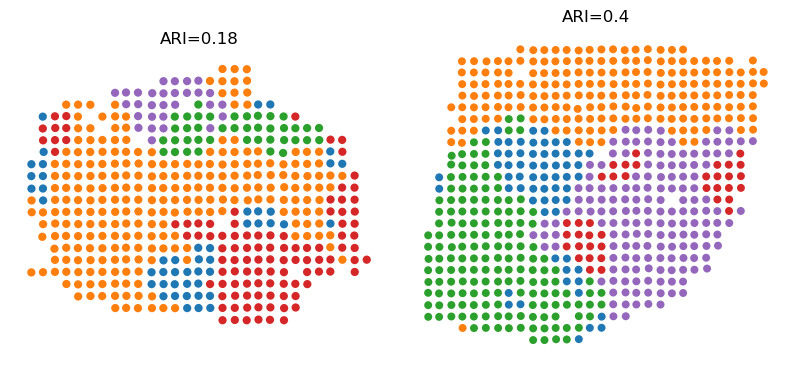

In [33]:
Batch_list = []
for section_id in section_ids:
    Batch_list.append(adata_concat[adata_concat.obs['batch_name'] == section_id])

import matplotlib.pyplot as plt
spot_size = 200
title_size = 12
ARI_list = []
for bb in range(2):
    ARI_list.append(round(ari_score(Batch_list[bb].obs['Ground Truth'], Batch_list[bb].obs['mclust']), 2))

fig, ax = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})
_sc_0 = sc.pl.spatial(Batch_list[0], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[0], frameon=False,
                      spot_size=spot_size)
_sc_0[0].set_title("ARI=" + str(ARI_list[0]), size=title_size)
_sc_1 = sc.pl.spatial(Batch_list[1], img_key=None, color=['mclust'], title=[''],
                      legend_loc=None, legend_fontsize=12, show=False, ax=ax[1], frameon=False,
                      spot_size=spot_size)
_sc_1[0].set_title("ARI=" + str(ARI_list[1]), size=title_size)
